In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Windows 系统通常使用 SimHei
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# Mac 系统通常使用 Arial Unicode MS
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

csv_file = r"D:\Project\DataAnalysis\OKX-HFT-BTC-USDT-2025-03--2025-10.csv"

In [25]:
df = pd.read_csv(csv_file, header=0)

In [26]:
df['volatility'] = (df['High'] - df['Low']) / df['Low']
df['dt'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['dt'].dt.hour
df['weekday'] = df['dt'].dt.weekday

In [27]:
df.head()

,Datetime,Timestamp,Open,High,Low,Close,Volume,volatility,dt,hour,weekday
0,2025-02-28T16:02:13.403000000,1740758533403000000,84067.9,84088.0,84036.2,84067.9,9.898627,0.000616,2025-02-28 16:02:13.403,16,4
1,2025-02-28T16:03:13.403000000,1740758593403000000,84067.9,84067.9,83886.4,84007.3,27.572105,0.002164,2025-02-28 16:03:13.403,16,4
2,2025-02-28T16:04:13.403000000,1740758653403000000,84003.8,84043.6,83782.1,83789.0,27.602951,0.003121,2025-02-28 16:04:13.403,16,4
3,2025-02-28T16:05:13.403000000,1740758713403000000,83788.1,83845.9,83743.7,83825.8,25.766227,0.001220,2025-02-28 16:05:13.403,16,4
4,2025-02-28T16:06:13.403000000,1740758773403000000,83825.9,83982.5,83825.9,83898.0,24.811745,0.001868,2025-02-28 16:06:13.403,16,4


In [28]:
pivot_df = df.pivot_table(
    index='weekday', 
    columns='hour', 
    values='volatility', 
    aggfunc='mean'
)

In [29]:
weekday_map = {
    0: '周一', 1: '周二', 2: '周三', 3: '周四', 
    4: '周五', 5: '周六', 6: '周日'
}
pivot_df.index = pivot_df.index.map(weekday_map)
week_order = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
pivot_df = pivot_df.reindex(week_order)

In [33]:
def plot_heatmap(df, col):
    pivot_df = df.pivot_table(
        index='weekday', 
        columns='hour', 
        values=col, 
        aggfunc='mean'
    )
    weekday_map = {
        0: '周一', 1: '周二', 2: '周三', 3: '周四', 
        4: '周五', 5: '周六', 6: '周日'
    }
    pivot_df.index = pivot_df.index.map(weekday_map)
    week_order = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
    pivot_df = pivot_df.reindex(week_order)

    plt.figure(figsize=(12, 6)) # 设置画布大小
    # 绘制
    sns.heatmap(
        pivot_df, 
        cmap='RdYlBu_r', # 颜色主题 (红黄蓝反转，红色代表高波动)
        annot=False,     # 是否在格子里显示数值，格子太多建议关掉
        fmt=".2f",       # 数值格式
        linewidths=0.5,  # 格子间隔
        cbar_kws={'label': f'平均{col}'} # 颜色条标签
    )

    # 设置标签
    plt.title(f'一周内各时段{col}热力图', fontsize=16)
    plt.xlabel('时间 (小时)', fontsize=12)
    plt.ylabel('星期', fontsize=12)

    # 优化X轴刻度显示 (显示 0点 到 23点)
    plt.xticks(rotation=0) 
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

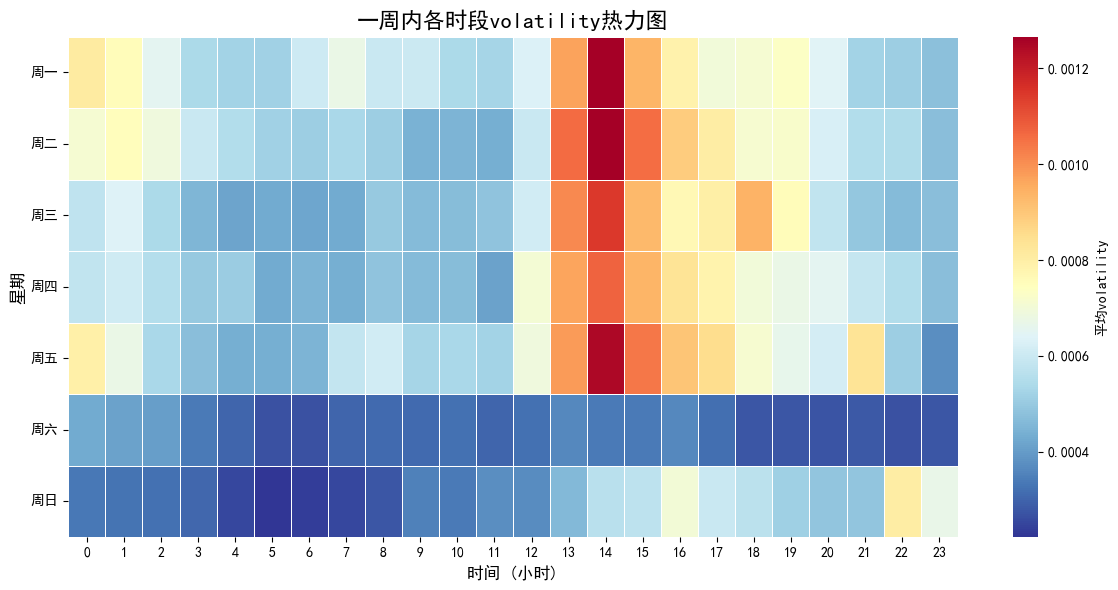

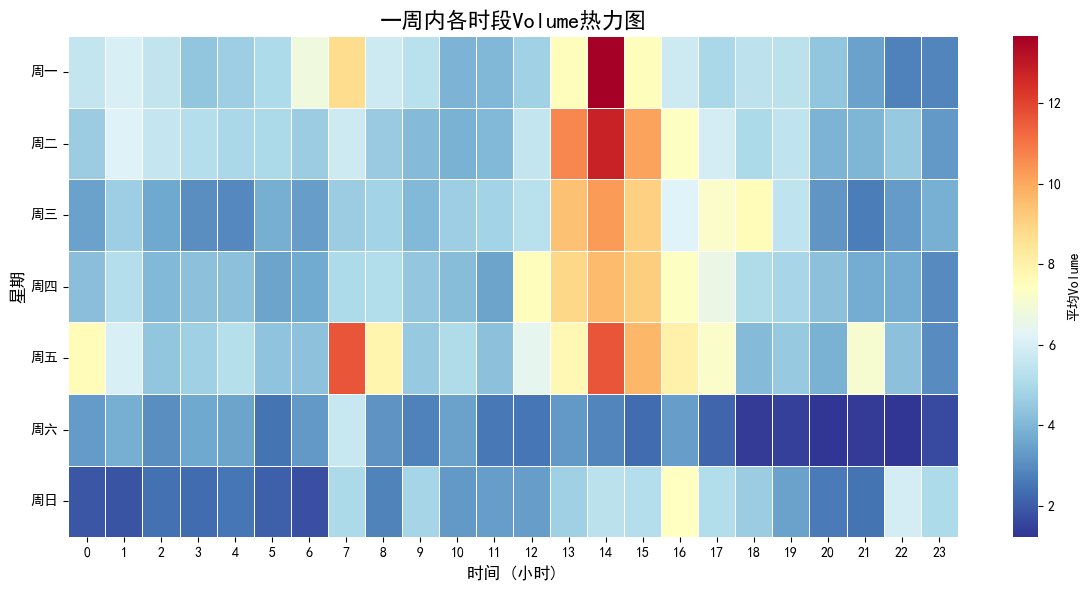

In [35]:
plot_heatmap(df, 'volatility')
plot_heatmap(df, 'Volume')

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
周一,0.000809,0.000755,0.000653,0.000536,0.000523,0.000517,0.000605,0.000671,0.000595,0.000601,...,0.001263,0.000939,0.000787,0.000696,0.000708,0.000732,0.000642,0.000523,0.000510,0.000477
周二,0.000707,0.000748,0.000690,0.000595,0.000549,0.000518,0.000510,0.000532,0.000511,0.000446,...,0.001265,0.001057,0.000890,0.000803,0.000713,0.000723,0.000622,0.000551,0.000547,0.000472
周三,0.000575,0.000637,0.000539,0.000452,0.000414,0.000427,0.000420,0.000429,0.000498,0.000463,...,0.001145,0.000927,0.000764,0.000800,0.000940,0.000755,0.000578,0.000493,0.000465,0.000474
周四,0.000580,0.000607,0.000552,0.000495,0.000505,0.000426,0.000448,0.000438,0.000483,0.000463,...,0.001071,0.000937,0.000835,0.000784,0.000696,0.000671,0.000654,0.000586,0.000552,0.000473
周五,0.000795,0.000673,0.000535,0.000474,0.000436,0.000437,0.000448,0.000583,0.000611,0.000525,...,0.001246,0.001039,0.000904,0.000850,0.000712,0.000665,0.000614,0.000835,0.000508,0.000376
